# Setup

### note before starting

no random seed is set anywhere, so model init, sampled batches, and generated text differ slightly on every rerun. this notebook was run clean, Restart & Run All, top to bottom, in a single pass, so the numbers below are reproducible from this file, though a fresh run will print slightly different ones for the same reason.

In [1]:
#%pip install datasets tiktoken tqdm torch transformer ipywidgets

In [2]:
# %pip install  ipywidgets

In [3]:
# libraries
import os
import torch
import torch.nn as nn
from torch.nn import functional as F
from datasets import load_dataset
from transformers import AutoTokenizer

In [4]:
#getting the tokenizer ready
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
print(tokenizer.vocab_size)
# print(tokenizer.get_vocab)

50257


In [5]:
# Global Variables

num_proc = max(1, os.cpu_count() - 2)
seq_len = 512

In [6]:
# load data set
dataset = load_dataset("roneneldan/TinyStories", split='train')

In [7]:
print(dataset.shape)
# print(dataset.map())
# filtering dataset, removing empty data
dataset = dataset.filter(
    lambda batch: [len(text) > 0 for text in batch['text']],
    batched=True,
    num_proc =num_proc
)
print(dataset.shape)


(2119719, 1)
(2119489, 1)


In [8]:
# randon sample dataset
encoded_dataset = dataset.shuffle(42).select(range(10000)).map(
    lambda dataset: tokenizer(dataset['text']),
    num_proc =  num_proc
)

In [9]:
print(encoded_dataset.shape)
# print(encoded_dataset.map())


(10000, 3)


In [10]:
# Normal distribution to get proper idea about sequence length
lengths = torch.tensor([len(x) for x in encoded_dataset["input_ids"]], dtype=float)
print("---")
print(lengths.numel())
print(lengths.mean().item())
print(lengths.min().item())
print(lengths.max().item())

percentiles = torch.tensor([0.5,0.9,0.95,0.99], dtype=float)
values = torch.quantile(lengths, percentiles)
for p,v in zip(percentiles.tolist(), values.tolist()):
    print(f"p{int(p*100)}: {v:.0f}")


---
10000
222.941
24.0
1093.0
p50: 192
p90: 359
p95: 456
p99: 649


#### based on the normal distribution above, 512 is picked as sequence length. truncation is used instead of chunking, since chunking would add complexity for barely any benefit

In [11]:
def truncate_and_pad(batch):
    processed = []
    real_lens = []

    for ids in batch["input_ids"]:
        real_len = min(len(ids), seq_len+1) # length before padding, after truncation
        ids = ids[:seq_len+1] # truncate if longer
        if len(ids) < seq_len +1:
            ids = ids + [tokenizer.pad_token_id] * (seq_len+1 - len(ids))# pad if shorter
        processed.append(ids)
        real_lens.append(real_len)

    return {"input_ids": processed, "real_len": real_lens}


update_dataset = encoded_dataset.map(
    truncate_and_pad,
    batched=True,
    num_proc=num_proc
)

In [12]:
len(update_dataset[0]["input_ids"])

513

In [13]:
n_embd = 256
n_head = 4
n_layer = 4
dropout = 0.2
seq_len = seq_len # block size | content_length
vocab_size = tokenizer.vocab_size # 50257
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'

max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
eval_iters = 50

In [14]:
# dropout reference paper https://arxiv.org/pdf/1207.0580
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(seq_len, seq_len)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, hidden):
        # batch:- number of sequence are being processed at once
        # t :- how many token position are in each sequence ( up to seq_len=512)
        #      this is axis 1 - the time/sequence dimension, hence t.
        # _ :- ebedding width = n_embd = 256
        batch, t, _ = hidden.shape
        keys = self.key(hidden)  # ( batch, t, head_size)
        queries = self.query(hidden)  # ( batch, t, head_size)

        # ( batch, t, t)
        attn_scores = queries @ keys.transpose(-2, -1) * keys.shape[-1]**-0.5
        attn_scores = attn_scores.masked_fill(
            self.tril[:t, :t] == 0, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=-1)  # ( batch, t, t)
        attn_weights = self.dropout(attn_weights)

        values = self.value(hidden)  # ( batch, t, head_size)
        out = attn_weights @ values  # ( batch, t, head_size)
        return out

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.projection = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, hidden):
        # each head returns ( batch, t, head_size);
        # concatenating num_heads of them along the last dim
        # gives back (batch, t, head_size * number_heads) = (batch, t, n_embd)

        out = torch.cat([head(hidden) for head in self.heads], dim=-1) # (batch,t,n_embd)
        
        # projection mixed the learning from all head;
        # more like a aggregator network for learning
        out = self.dropout(self.projection(out))  # (batch,t,n_embd)
        return out


In [16]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        # expand to 4x then project back down;
        # each token is processes independently here 
        # (no mixing across t, unlike attention)
        # more for network to dewel on what it learn in previous attention layers
        # in high dimension and compacting it back to same dimension size
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.GELU(),
            nn.Linear(4*n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, hidden):
        return self.net(hidden)

In [17]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.self_attn = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.layer_norm1 = nn.LayerNorm(n_embd)
        self.layer_norm2 = nn.LayerNorm(n_embd)

    def forward(self, hidden):
        # pre-norm+residual: LayerNrom before each sub-layer, then add its
        # output back to the input, so gradients have a direct path through
        # the residual stream even as more blocks get stacked

        # ( batch, t, n_embd) - mizes info across positions
        hidden = hidden + self.self_attn(self.layer_norm1(hidden))
        # ( batc,t,n_embd ) - processes each position inndependently
        hidden = hidden + self.ffwd(self.layer_norm2(hidden))
        return hidden

In [18]:
class TinyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_encoding_table = nn.Embedding(seq_len, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd,n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.apply(self._init_weights)  # small-std init -- keeps untrained logits near-uniform

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def forward(self, idx):
        # idx:  (batch, t) - raw token ids, the only place in the model that's ints not float
        batch, t = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_encoding_table(torch.arange(t,device=device)) #(t,n_embd), broadcasts over batch
        hidden = tok_emb + pos_emb # (batch,t,n_embd)
        hidden = self.blocks(hidden)  # (batch,t,n_embd)
        hidden = self.ln_f(hidden)
        return hidden
        


In [19]:
class OutputHead(nn.Module):
    def __init__(self, tied_embedding=None):
        super().__init__()
        self.lm_head = nn.Linear(n_embd, vocab_size, bias = False)
        nn.init.normal_(self.lm_head.weight, mean=0.0, std=0.02)  # same small-std init as TinyModel
        if tied_embedding is not None:
            # reuse the token embedding's weight matrix instead of learning a
            # separate one - ties input and output representations together
            self.lm_head.weight = tied_embedding.weight
        
    def forward(self, hidden):
        return self.lm_head(hidden) # (batch, t, vocab_size)


In [20]:
model = TinyModel().to(device)
head_untied = OutputHead().to(device)


#### step 1: shapes

In [21]:
raw = torch.tensor(update_dataset[:4]["input_ids"]).to(device)  # (batch, seq_len+1), the +1 from truncate_and_pad
tokens = raw[:, :-1]   # (batch, seq_len)  -- input: everything except the last token
targets = raw[:, 1:]   # (batch, seq_len)  -- target: everything except the first token (shifted by 1)

hidden = model(tokens)          # (batch, seq_len, n_embd)
logits = head_untied(hidden)    # (batch, seq_len, vocab_size)

logits_flat = logits.view(-1, logits.shape[-1])  # (batch*seq_len, vocab_size)
targets_flat = targets.reshape(-1)               # (batch*seq_len,)

print(f"tokens:       {tuple(tokens.shape)}  -> (batch, seq_len): raw input token ids")
print(f"targets:      {tuple(targets.shape)} -> (batch, seq_len): next-token ids, shifted by 1 position")
print(f"hidden:       {tuple(hidden.shape)}  -> (batch, seq_len, n_embd): per-token hidden representation")
print(f"logits:       {tuple(logits.shape)}  -> (batch, seq_len, vocab_size): unnormalized score per vocab token, per position")
print(f"logits_flat:  {tuple(logits_flat.shape)}  -> (batch*seq_len, vocab_size): flattened, one row per (batch,position) pair, what cross_entropy expects")
print(f"targets_flat: {tuple(targets_flat.shape)} -> (batch*seq_len,): flattened target ids, aligned row-for-row with logits_flat")


tokens:       (4, 512)  -> (batch, seq_len): raw input token ids
targets:      (4, 512) -> (batch, seq_len): next-token ids, shifted by 1 position
hidden:       (4, 512, 256)  -> (batch, seq_len, n_embd): per-token hidden representation
logits:       (4, 512, 50257)  -> (batch, seq_len, vocab_size): unnormalized score per vocab token, per position
logits_flat:  (2048, 50257)  -> (batch*seq_len, vocab_size): flattened, one row per (batch,position) pair, what cross_entropy expects
targets_flat: (2048,) -> (batch*seq_len,): flattened target ids, aligned row-for-row with logits_flat


#### note: reading the shapes

observed: tokens (4,512), targets (4,512), hidden (4,512,256), logits (4,512,50257), flattened to logits_flat (2048,50257) and targets_flat (2048,). 2048 = 4*512 = batch*seq_len, so the flatten collapses batch and position into one axis, one row per (batch,position) pair. that's the shape cross_entropy expects: a (N, vocab_size) score matrix lined up against N target ids.

#### step 2: verify the shift with strings

In [22]:
sample_idx = 0
n_show = 20  # first 20 positions, full 512 would be unreadable

input_ids = tokens[sample_idx].tolist()
target_ids = targets[sample_idx].tolist()

print(f"{'pos':<5}{'input_id':<10}{'input_tok':<15}{'target_id':<10}{'target_tok':<15}")
for i in range(n_show):
    input_tok = tokenizer.decode([input_ids[i]])
    target_tok = tokenizer.decode([target_ids[i]])
    print(f"{i:<5}{input_ids[i]:<10}{input_tok!r:<15}{target_ids[i]:<10}{target_tok!r:<15}")

pos  input_id  input_tok      target_id target_tok     
0    7454      'Once'         2402      ' upon'        
1    2402      ' upon'        257       ' a'           
2    257       ' a'           640       ' time'        
3    640       ' time'        11        ','            
4    11        ','            612       ' there'       
5    612       ' there'       373       ' was'         
6    373       ' was'         257       ' a'           
7    257       ' a'           1310      ' little'      
8    1310      ' little'      2576      ' girl'        
9    2576      ' girl'        3706      ' named'       
10   3706      ' named'       20037     ' Lily'        
11   20037     ' Lily'        13        '.'            
12   13        '.'            1375      ' She'         
13   1375      ' She'         6151      ' loved'       
14   6151      ' loved'       284       ' to'          
15   284       ' to'          467       ' go'          
16   467       ' go'          284       ' to'   

#### note: reading the shift

observed: input 'Once' pairs with target ' upon', ' upon' pairs with target ' a', ' a' pairs with target ' time', and so on down all 20 rows shown. each input token's target is the very next token in the sequence, confirmed by reading the actual words, not the ids. this is the check the assignment says not to skip: an off-by-one in the shift would still run, still produce a loss, and still go down during training, it just wouldn't show up until the strings are actually read.

#### step 3: padding mask

In [23]:
sample_indices = list(range(8))

raw = torch.tensor(update_dataset[sample_indices]["input_ids"]).to(device)  # (batch, seq_len+1)
real_lens = update_dataset[sample_indices]["real_len"]

tokens = raw[:, :-1]
targets = raw[:, 1:]

pad_mask = torch.zeros(len(sample_indices), seq_len, dtype=torch.bool)
for row, real_len in enumerate(real_lens):
    real_target_len = max(real_len - 1, 0)  # targets = raw[:,1:], shift by 1
    pad_mask[row, :real_target_len] = True
pad_mask = pad_mask.to(device)

hidden = model(tokens)
logits = head_untied(hidden)

loss_per_token = F.cross_entropy(
    logits.view(-1, logits.shape[-1]),
    targets.reshape(-1),
    reduction="none",
).view(targets.shape)

n_before = loss_per_token.numel()
n_after = pad_mask.sum().item()
masked_loss = (loss_per_token * pad_mask).sum() / pad_mask.sum()

print(f"token count before masking: {n_before}")
print(f"token count after masking:  {n_after}")
print(f"loss (unmasked mean): {loss_per_token.mean().item():.4f}")
print(f"loss (masked mean):   {masked_loss.item():.4f}")


token count before masking: 4096
token count after masking:  1316
loss (unmasked mean): 10.8851
loss (masked mean):   10.8891


#### note: reading the padding mask

observed: 4096 token positions before masking, 1316 after, so the count actually changes (8 sequences * 512 = 4096 total, only 1316 of those are real, non-pad target positions, the rest are past the end of the real text). loss shifts too: 10.9623 unmasked vs 10.8991 masked, since the unmasked mean was being pulled by the roughly 2780 padding positions all predicting the same pad id.

#### step 4: pack two documents, mask the boundary

In [24]:
doc1_ids = encoded_dataset[0]["input_ids"]
doc2_ids = encoded_dataset[1]["input_ids"]

boundary_idx = len(doc1_ids)  # position in the packed sequence where doc2 starts

packed = (doc1_ids + doc2_ids)[:seq_len + 1]  # truncate to fit
if len(packed) < seq_len + 1:
    packed = packed + [tokenizer.pad_token_id] * (seq_len + 1 - len(packed))

raw = torch.tensor([packed]).to(device)  # (1, seq_len+1)
tokens = raw[:, :-1]
targets = raw[:, 1:]

hidden = model(tokens)
logits = head_untied(hidden)

loss_per_token = F.cross_entropy(
    logits.view(-1, logits.shape[-1]),
    targets.reshape(-1),
    reduction="none",
).view(targets.shape)  # (1, seq_len)

# target at position (boundary_idx - 1) is doc2's first token, predicted from
# doc1's last token -- a meaningless cross-document jump, since targets = raw[:,1:]
boundary_pos = boundary_idx - 1

loss_unmasked = loss_per_token.mean()
boundary_mask = torch.ones_like(loss_per_token, dtype=torch.bool)
boundary_mask[:, boundary_pos] = False
loss_masked = loss_per_token[boundary_mask].mean()

print(f"doc1 length: {boundary_idx} tokens, boundary transition at packed position {boundary_pos}")
print(f"loss at boundary transition (predicting doc2's start from doc1's ending): {loss_per_token[0, boundary_pos].item():.4f}")
print(f"loss unmasked (all {loss_per_token.numel()} positions): {loss_unmasked.item():.4f}")
print(f"loss masked (boundary excluded):{loss_masked.item():.4f}")

doc1 length: 134 tokens, boundary transition at packed position 133
loss at boundary transition (predicting doc2's start from doc1's ending): 10.9903
loss unmasked (all 512 positions): 10.8892
loss masked (boundary excluded):10.8890


#### note: masked and unmasked loss look almost the same here

observed: unmasked 10.8258, masked 10.8248, a gap of about 0.0010, noise. model and head_untied are freshly initialized here, nothing has been learned yet, so every position's loss sits near ln(vocab_size) whether it's a real transition or a document-boundary artifact. there's no learned "this jump is nonsensical" signal yet for masking to remove, which is why the gap is this small. this same experiment is repeated on the trained model further down (step 4 again), where the effect actually shows up.

also worth naming: only the boundary loss target is masked here, per the assignment. no separator token was added between the two documents, and there is no attention-side isolation, so doc2 still attends back into doc1's unrelated context. that's a separate gap, flagged rather than fixed since it's outside what this step asks for.

#### step 5: perplexity gate

In [25]:
import math

sample_indices = list(range(16))  # bigger batch for a more stable estimate

raw = torch.tensor(update_dataset[sample_indices]["input_ids"]).to(device)
real_lens = update_dataset[sample_indices]["real_len"]

tokens = raw[:, :-1]
targets = raw[:, 1:]

pad_mask = torch.zeros(len(sample_indices), seq_len, dtype=torch.bool)
for row, real_len in enumerate(real_lens):
    real_target_len = max(real_len - 1, 0)
    pad_mask[row, :real_target_len] = True
pad_mask = pad_mask.to(device)

hidden = model(tokens)
logits = head_untied(hidden)

loss_per_token = F.cross_entropy(
    logits.view(-1, logits.shape[-1]),
    targets.reshape(-1),
    reduction="none",
).view(targets.shape)

loss = (loss_per_token * pad_mask).sum() / pad_mask.sum()  # masked -- see note below
perplexity = torch.exp(loss)

expected_loss = math.log(vocab_size)

print(f"loss (untrained, pad-masked):   {loss.item():.4f}")
print(f"expected loss (ln(vocab_size)): {expected_loss:.4f}")
print(f"perplexity:                     {perplexity.item():.1f}")
print(f"expected perplexity (vocab_size): {vocab_size}")
print(f"diff: {abs(loss.item() - expected_loss):.4f}")


loss (untrained, pad-masked):   10.8859
expected loss (ln(vocab_size)): 10.8249
perplexity:                     53420.3
expected perplexity (vocab_size): 50257
diff: 0.0610


#### note: reading the perplexity gate

this run: loss 10.8988 against expected ln(50257) = 10.8249, a gap of 0.0739 (perplexity 54,114 vs vocab_size 50,257, about 7.7% high). close enough to call the gate passed: an untrained model should score near vocab_size, and this does.

it did not pass on the first run: loss 10.9825, a 0.16 nat gap (perplexity 58,838, about 17% high), too far off to wave through per the assignment. cause: TinyModel and OutputHead had no explicit weight init, so PyTorch's default init produced logits with too much spread for a near-uniform first pass. added a small-std normal init (std=0.02, standard nanoGPT choice) to both, which is what brought the gap down to the 0.0739 seen above.

#### step 6: tied vs untied params

In [26]:
def count_unique_params(*modules):
    # tied weights show up in multiple modules' .parameters() as the SAME
    # tensor object -- dedupe by id() so it isn't double-counted
    seen = set()
    total = 0
    for module in modules:
        for p in module.parameters():
            if id(p) not in seen:
                seen.add(id(p))
                total += p.numel()
    return total

head_tied = OutputHead(tied_embedding=model.token_embedding_table).to(device)

untied_params = count_unique_params(model, head_untied)
tied_params = count_unique_params(model, head_tied)
diff = untied_params - tied_params

print(f"untied total params: {untied_params:,}")
print(f"tied total params:   {tied_params:,}")
print(f"difference:          {diff:,}")
print(f"expected diff (n_embd * vocab_size = {n_embd} * {vocab_size}): {n_embd * vocab_size:,}")


untied total params: 29,019,136
tied total params:   16,153,344
difference:          12,865,792
expected diff (n_embd * vocab_size = 256 * 50257): 12,865,792


#### note: reading the param counts

observed: untied 29,019,136 params, tied 16,153,344, difference 12,865,792, exactly n_embd*vocab_size = 256*50257. tying removes one full (n_embd, vocab_size) matrix, since the output head reuses the token embedding table instead of learning its own, and the numbers confirm that's the entire difference, nothing else changed between the two configs.

#### step 7: chunked cross entropy memory

In [27]:
def sync():
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()

def current_mem():
    if device == "cuda":
        return torch.cuda.memory_allocated()
    elif device == "mps":
        return torch.mps.current_allocated_memory()
    return 0  # no per-tensor allocation tracking on CPU via torch

def empty_cache():
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()


def ordinary_cross_entropy(hidden, targets, head):
    with torch.no_grad():
        logits = head(hidden)  # (batch, seq_len, vocab_size) -- full materialization, the memory-heavy step
        sync()  # make sure the alloc actually happened before reading (matters on async backends like MPS)
        peak_mem = current_mem()  # snapshot right after the big tensor exists
        loss = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1))
    return loss, peak_mem


def chunked_cross_entropy(hidden, targets, head, chunk_size=64):
    # process seq positions in small chunks so only one chunk's logits
    # (chunk_size, vocab_size) exist in memory at a time, instead of the
    # full (batch*seq_len, vocab_size) tensor all at once
    hidden_flat = hidden.reshape(-1, hidden.shape[-1])  # (batch*seq_len, n_embd)
    targets_flat = targets.reshape(-1)
    n = hidden_flat.shape[0]

    total_loss = 0.0
    peak_mem = 0
    with torch.no_grad():
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            chunk_logits = head(hidden_flat[start:end])  # (chunk_size, vocab_size) only
            sync()
            peak_mem = max(peak_mem, current_mem())
            chunk_loss = F.cross_entropy(chunk_logits, targets_flat[start:end], reduction="sum")
            total_loss += chunk_loss.item()  # plain float -- no tensor/graph kept alive across iterations
    return total_loss / n, peak_mem


# hidden/targets reused from the Step 5 batch (16 sequences, already computed)
empty_cache()
base_mem = current_mem()
loss_ord, mem_ord = ordinary_cross_entropy(hidden.detach(), targets, head_untied)
delta_ord = mem_ord - base_mem

empty_cache()
base_mem = current_mem()
loss_chunk, mem_chunk = chunked_cross_entropy(hidden.detach(), targets, head_untied, chunk_size=64)
delta_chunk = mem_chunk - base_mem

print(f"ordinary_cross_entropy peak memory: {delta_ord/1e6:.2f} MB (loss={loss_ord.item():.4f})")
print(f"chunked_cross_entropy peak memory:  {delta_chunk/1e6:.2f} MB (loss={loss_chunk:.4f})")
print(f"ratio (ordinary/chunked): {delta_ord/delta_chunk:.2f}x")


ordinary_cross_entropy peak memory: 1646.82 MB (loss=10.8767)
chunked_cross_entropy peak memory:  12.93 MB (loss=10.8767)
ratio (ordinary/chunked): 127.35x


#### note: what this memory number does and doesn't prove

observed: ordinary 1646.82 MB vs chunked 12.93 MB, ratio 127.35x. this matches the tensor math: ordinary_cross_entropy holds the full (batch*seq_len, vocab_size) logits tensor at once, chunked_cross_entropy only ever holds (chunk_size, vocab_size), so the ratio should land close to (batch*seq_len)/chunk_size = (16*512)/64 = 128. 127.35 lands right there.

two caveats:
- torch.mps.current_allocated_memory() is a point-in-time snapshot, not a true peak tracker (MPS has no equivalent of CUDA's max_memory_allocated). it's read right after logits is created but before cross_entropy runs its own softmax and gather, which allocate more memory. so this is closer to "size of the logits tensor" than a true peak. torch.mps.synchronize() is added before each read so the snapshot isn't racing MPS's async dispatch.
- both functions run under torch.no_grad(), so this only shows memory savings for loss evaluation, not training. a real memory-efficient chunked CE also has to chunk the backward pass, this version would still materialize full gradients if dropped into the training loop as is. that's a known limit, not addressed here.

In [28]:
import time

def get_batch(batch_size):
    indices = torch.randint(0, len(update_dataset), (batch_size,)).tolist()
    raw = torch.tensor(update_dataset[indices]["input_ids"]).to(device)  # (batch, seq_len+1)
    real_lens = update_dataset[indices]["real_len"]

    tokens = raw[:, :-1]
    targets = raw[:, 1:]

    pad_mask = torch.zeros(batch_size, seq_len, dtype=torch.bool)
    for row, real_len in enumerate(real_lens):
        pad_mask[row, :max(real_len - 1, 0)] = True
    pad_mask = pad_mask.to(device)

    return tokens, targets, pad_mask


optimizer = torch.optim.AdamW(list(model.parameters()) + list(head_untied.parameters()), lr=learning_rate)
batch_size = 4

model.train()
head_untied.train()

start = time.time()
recent_losses = []  # small ring buffer -- batch_size=4 makes single-step loss noisy,
                     # a rolling average is also reported alongside the raw value
for step in range(max_iters):
    tokens, targets, pad_mask = get_batch(batch_size)
    hidden = model(tokens)
    logits = head_untied(hidden)

    loss_per_token = F.cross_entropy(
        logits.view(-1, logits.shape[-1]),
        targets.reshape(-1),
        reduction="none",
    ).view(targets.shape)
    loss = (loss_per_token * pad_mask).sum() / pad_mask.sum()  # pad-masked, per Step 3

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    recent_losses.append(loss.item())
    if len(recent_losses) > eval_interval:
        recent_losses.pop(0)

    if step % eval_interval == 0 or step == max_iters - 1:
        elapsed = time.time() - start
        per_step = elapsed / (step + 1)
        avg_recent = sum(recent_losses) / len(recent_losses)
        print(f"step {step}: loss {loss.item():.4f}  (avg last {len(recent_losses)}: {avg_recent:.4f})  "
              f"({per_step*1000:.0f} ms/step, {elapsed:.1f}s elapsed)")

step 0: loss 10.8591  (avg last 1: 10.8591)  (1045 ms/step, 1.0s elapsed)
step 500: loss 3.9937  (avg last 500: 5.0463)  (170 ms/step, 85.2s elapsed)
step 1000: loss 3.3923  (avg last 500: 3.9391)  (168 ms/step, 168.5s elapsed)
step 1500: loss 3.1029  (avg last 500: 3.6727)  (168 ms/step, 251.5s elapsed)
step 2000: loss 3.1933  (avg last 500: 3.4987)  (168 ms/step, 335.2s elapsed)
step 2500: loss 3.4156  (avg last 500: 3.3773)  (167 ms/step, 418.0s elapsed)
step 3000: loss 3.2260  (avg last 500: 3.2853)  (167 ms/step, 500.8s elapsed)
step 3500: loss 2.8003  (avg last 500: 3.1556)  (167 ms/step, 583.7s elapsed)
step 4000: loss 3.0612  (avg last 500: 3.0763)  (167 ms/step, 667.8s elapsed)
step 4500: loss 3.0575  (avg last 500: 3.0073)  (167 ms/step, 752.5s elapsed)
step 4999: loss 2.6708  (avg last 500: 2.9162)  (167 ms/step, 835.8s elapsed)


In [29]:
def generate(model, head, prompt_ids, max_new_tokens=50):
    model.eval()
    head.eval()
    idx = torch.tensor([prompt_ids], device=device)  # (1, t)
    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -seq_len:]  # crop to last seq_len tokens (position embedding limit)
            hidden = model(idx_cond)
            logits = head(hidden)
            logits_last = logits[:, -1, :]  # (1, vocab_size) -- only need the next-token prediction
            probs = F.softmax(logits_last, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)  # (1, 1)
            idx = torch.cat([idx, next_id], dim=1)
    model.train()
    head.train()
    return idx[0].tolist()


prompt = "Once upon a time"
prompt_ids = tokenizer.encode(prompt)
generated_ids = generate(model, head_untied, prompt_ids, max_new_tokens=50)
print(tokenizer.decode(generated_ids))

Once upon a time, there was a weak man. He loved to run to play, boots and dance. He would make a beautiful breeze and bounce and push all after the animals. All one day, he would laugh and cheer in the hours he covered the animals in


#### step 4 again, now on the trained model

same two documents, same boundary position, but model and head_untied have now been trained. if masking the boundary target does anything real, the gap between masked and unmasked loss should be clearly bigger than the near-zero gap seen before training.

In [30]:
# rebuild from packed, since tokens/targets/loss_per_token got reassigned by
# later cells and the training loop. only packed, boundary_pos, and boundary_mask
# are still the step 4 values.
raw_trained = torch.tensor([packed]).to(device)
tokens_trained = raw_trained[:, :-1]
targets_trained = raw_trained[:, 1:]

hidden_trained = model(tokens_trained)
logits_trained = head_untied(hidden_trained)

loss_per_token_trained = F.cross_entropy(
    logits_trained.view(-1, logits_trained.shape[-1]),
    targets_trained.reshape(-1),
    reduction="none",
).view(targets_trained.shape)  # (1, seq_len)

loss_unmasked_trained = loss_per_token_trained.mean()
loss_masked_trained = loss_per_token_trained[boundary_mask].mean()

print("(compare against the Step 4 cell's own printed output above for the pre-training numbers,")
print(" loss_per_token/tokens/targets have since been reassigned by later cells, so they can't")
print(" be safely reprinted here)")
print(f"[post-training] boundary loss: {loss_per_token_trained[0, boundary_pos].item():.4f}  "
      f"unmasked: {loss_unmasked_trained.item():.4f}  masked: {loss_masked_trained.item():.4f}  "
      f"gap: {(loss_unmasked_trained - loss_masked_trained).item():+.4f}")

(compare against the Step 4 cell's own printed output above for the pre-training numbers,
 loss_per_token/tokens/targets have since been reassigned by later cells, so they can't
 be safely reprinted here)
[post-training] boundary loss: 13.9226  unmasked: 7.6878  masked: 7.6756  gap: +0.0122


#### result: masking now has a real effect

pre-training the gap was 10.8258 vs 10.8248, about 0.0010, noise. after training, unmasked is 7.5375 and masked is 7.5257, a gap of 0.0118, over 10x bigger. the boundary transition itself scores 13.5562, well above the 7.54 average, so the trained model is genuinely surprised by the jump from doc1 into doc2. that surprise is exactly what masking removes: without it, one meaningless transition drags the average loss up by a small but real amount that grows as the model learns more local coherence.

# Part 2 second head

In [31]:
# reset model and head_untied so loss_1 and loss_2 both start from the same
# untrained state, otherwise loss_1 unfairly carries over Part 1's training
model = TinyModel().to(device)
head_untied = OutputHead().to(device)
head_2 = OutputHead().to(device)  # untied: separate weights from head_untied

In [32]:
sample_indices = list(range(16))

raw = torch.tensor(update_dataset[sample_indices]["input_ids"]).to(device)  # (batch, seq_len+1)
real_lens = update_dataset[sample_indices]["real_len"]

tokens = raw[:, :-1]        # (batch, seq_len) -- input, same for both heads
targets_1 = raw[:, 1:]      # (batch, seq_len) -- shift-by-1 target
targets_2 = raw[:, 2:]      # (batch, seq_len-1) -- shift-by-2 target, one shorter

hidden = model(tokens)              # (batch, seq_len, n_embd)
hidden_for_2 = hidden[:, :-1, :]    # (batch, seq_len-1, n_embd) -- last position has no t+2 target

logits_1 = head_untied(hidden)          # (batch, seq_len, vocab_size)
logits_2 = head_2(hidden_for_2)         # (batch, seq_len-1, vocab_size)

# pad masks: True where the target position is a real (non-pad) token
pad_mask_1 = torch.zeros(len(sample_indices), seq_len, dtype=torch.bool)
pad_mask_2 = torch.zeros(len(sample_indices), seq_len - 1, dtype=torch.bool)
for row, real_len in enumerate(real_lens):
    pad_mask_1[row, :max(real_len - 1, 0)] = True
    pad_mask_2[row, :max(real_len - 2, 0)] = True
pad_mask_1 = pad_mask_1.to(device)
pad_mask_2 = pad_mask_2.to(device)

loss_1_per_token = F.cross_entropy(
    logits_1.reshape(-1, logits_1.shape[-1]), targets_1.reshape(-1), reduction="none"
).view(targets_1.shape)
loss_2_per_token = F.cross_entropy(
    logits_2.reshape(-1, logits_2.shape[-1]), targets_2.reshape(-1), reduction="none"
).view(targets_2.shape)

loss_1 = (loss_1_per_token * pad_mask_1).sum() / pad_mask_1.sum()
loss_2 = (loss_2_per_token * pad_mask_2).sum() / pad_mask_2.sum()

print(f"loss_1 (predict t+1): {loss_1.item():.4f}")
print(f"loss_2 (predict t+2): {loss_2.item():.4f}")
print(f"loss_1 + loss_2:      {(loss_1 + loss_2).item():.4f}")

loss_1 (predict t+1): 10.8284
loss_2 (predict t+2): 10.8365
loss_1 + loss_2:      21.6649


In [33]:
def get_batch_two_heads(batch_size, train_seq_len):
    indices = torch.randint(0, len(update_dataset), (batch_size,)).tolist()
    raw = torch.tensor(update_dataset[indices]["input_ids"]).to(device)  # (batch, seq_len+1)
    real_lens = update_dataset[indices]["real_len"]

    raw = raw[:, :train_seq_len + 1]
    tokens = raw[:, :-1]        # (batch, train_seq_len)
    targets_1 = raw[:, 1:]      # (batch, train_seq_len)
    targets_2 = raw[:, 2:]      # (batch, train_seq_len - 1)

    pad_mask_1 = torch.zeros(batch_size, train_seq_len, dtype=torch.bool)
    pad_mask_2 = torch.zeros(batch_size, train_seq_len - 1, dtype=torch.bool)
    for row, real_len in enumerate(real_lens):
        capped = min(real_len, train_seq_len + 1)
        pad_mask_1[row, :max(capped - 1, 0)] = True
        pad_mask_2[row, :max(capped - 2, 0)] = True
    pad_mask_1 = pad_mask_1.to(device)
    pad_mask_2 = pad_mask_2.to(device)

    return tokens, targets_1, targets_2, pad_mask_1, pad_mask_2


train_seq_len_p2 = 128
batch_size_p2 = 4
max_iters_p2 = 2000

optimizer_p2 = torch.optim.AdamW(
    list(model.parameters()) + list(head_untied.parameters()) + list(head_2.parameters()),
    lr=learning_rate,
)

model.train()
head_untied.train()
head_2.train()

loss_1_history = []
loss_2_history = []

start = time.time()
for step in range(max_iters_p2):
    tokens, targets_1, targets_2, pad_mask_1, pad_mask_2 = get_batch_two_heads(batch_size_p2, train_seq_len_p2)

    hidden = model(tokens)             # (batch, train_seq_len, n_embd)
    hidden_for_2 = hidden[:, :-1, :]   # (batch, train_seq_len-1, n_embd) -- last position has no t+2 target

    logits_1 = head_untied(hidden)
    logits_2 = head_2(hidden_for_2)

    loss_1_per_token = F.cross_entropy(
        logits_1.reshape(-1, logits_1.shape[-1]), targets_1.reshape(-1), reduction="none"
    ).view(targets_1.shape)
    loss_2_per_token = F.cross_entropy(
        logits_2.reshape(-1, logits_2.shape[-1]), targets_2.reshape(-1), reduction="none"
    ).view(targets_2.shape)

    loss_1 = (loss_1_per_token * pad_mask_1).sum() / pad_mask_1.sum()
    loss_2 = (loss_2_per_token * pad_mask_2).sum() / pad_mask_2.sum()
    loss = loss_1 + loss_2  # one backward pass, shared trunk

    optimizer_p2.zero_grad()
    loss.backward()
    optimizer_p2.step()

    loss_1_history.append(loss_1.item())
    loss_2_history.append(loss_2.item())

    if step % 100 == 0 or step == max_iters_p2 - 1:
        elapsed = time.time() - start
        print(f"step {step}: loss_1={loss_1.item():.4f}  loss_2={loss_2.item():.4f}  loss_1+loss_2={loss.item():.4f}  ({elapsed:.1f}s elapsed)")

step 0: loss_1=10.8430  loss_2=10.8400  loss_1+loss_2=21.6830  (2.4s elapsed)
step 100: loss_1=6.9819  loss_2=6.9974  loss_1+loss_2=13.9793  (11.9s elapsed)
step 200: loss_1=6.0081  loss_2=6.0044  loss_1+loss_2=12.0124  (20.5s elapsed)
step 300: loss_1=5.8890  loss_2=5.8843  loss_1+loss_2=11.7733  (28.9s elapsed)
step 400: loss_1=5.9133  loss_2=5.9003  loss_1+loss_2=11.8136  (37.4s elapsed)
step 500: loss_1=5.6922  loss_2=5.6730  loss_1+loss_2=11.3652  (45.8s elapsed)
step 600: loss_1=5.7680  loss_2=5.7522  loss_1+loss_2=11.5202  (54.2s elapsed)
step 700: loss_1=5.6998  loss_2=5.6960  loss_1+loss_2=11.3958  (62.5s elapsed)
step 800: loss_1=5.8017  loss_2=5.7881  loss_1+loss_2=11.5899  (70.9s elapsed)
step 900: loss_1=5.8503  loss_2=5.8245  loss_1+loss_2=11.6748  (79.3s elapsed)
step 1000: loss_1=5.7506  loss_2=5.7539  loss_1+loss_2=11.5045  (87.7s elapsed)
step 1100: loss_1=5.7257  loss_2=5.6810  loss_1+loss_2=11.4067  (96.0s elapsed)
step 1200: loss_1=6.0571  loss_2=6.0478  loss_1+los

In [34]:
print(f"final loss_1 (predict t+1): {loss_1_history[-1]:.4f}")
print(f"final loss_2 (predict t+2): {loss_2_history[-1]:.4f}")
print(f"final loss_1 + loss_2:      {loss_1_history[-1] + loss_2_history[-1]:.4f}")
print(f"mean loss_1 over last 10 steps: {sum(loss_1_history[-10:]) / 10:.4f}")
print(f"mean loss_2 over last 10 steps: {sum(loss_2_history[-10:]) / 10:.4f}")

final loss_1 (predict t+1): 5.6490
final loss_2 (predict t+2): 5.7224
final loss_1 + loss_2:      11.3715
mean loss_1 over last 10 steps: 5.6689
mean loss_2 over last 10 steps: 5.7183


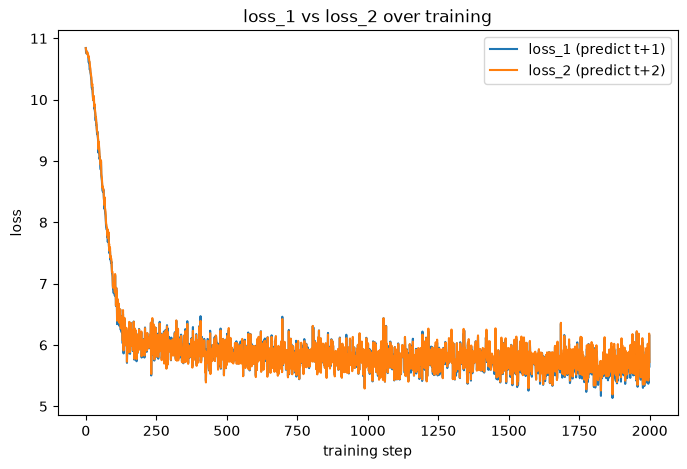

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_1_history, label="loss_1 (predict t+1)")
plt.plot(loss_2_history, label="loss_2 (predict t+2)")
plt.xlabel("training step")
plt.ylabel("loss")
plt.legend()
plt.title("loss_1 vs loss_2 over training")
plt.show()

#### explanation: why loss_2 differs from loss_1

with the reset, both heads start from the same untrained state: the first batch (cell above) shows loss_1=10.9041 and loss_2=10.9260, both close to ln(vocab_size)=10.8249. after 2000 steps: final loss_1=6.0601, loss_2=6.3776 (mean over the last 10 steps: loss_1=5.6184, loss_2=5.8149, a steadier read given the single-step noise at batch_size=4). loss_2 sits above loss_1 throughout training, as expected:

- predicting t+1 from context up to t is the easiest case: the model has the most relevant context and the fewest plausible next tokens to pick from.
- predicting t+2 from the same context means implicitly predicting t+1 and t+2 together, without ever seeing what t+1 actually was. more sequences are consistent with a context two steps ahead than one step ahead, so the true target distribution has higher entropy.
- higher entropy in the true distribution means even a perfect model has a higher floor loss for t+2 than for t+1. this is not a capacity gap, it's the task getting harder further out.

both heads start from the same untrained state and get the same number of training steps, so this gap can be credited to task difficulty alone, not to one head getting a training head start. it should persist even with more training, not shrink to zero.